In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
#load processed data
client_data = pd.read_csv('../data/processed/client_data_with_segments.csv')
trades = pd.read_csv('../data/processed/trades_processed.csv')

print("🔎 Dataset Previews:")
print("\nClient Data:")
display(client_data.head())

print("\nTrades Data:")
display(trades.head())

#convert data columns
trades['transaction_date'] = pd.to_datetime(trades['transaction_date'])
client_data['join_date'] = pd.to_datetime(client_data['join_date'])

🔎 Dataset Previews:

Client Data:


,client_id,age,income_bracket,risk_tolerance,investment_experience,join_date,country,tenure_days,account_balance,last_updated,...,total_transaction_value,transaction_count,deposit_ratio,avg_daily_trades,value_per_trade,cluster,volatility_score,activity_score,size_score,behavioral_risk_score
0,C10000,54,Medium,Very High,Beginner,2020-02-16,Canada,2040,11119,2025-09-16 18:10:22.208536,...,52091.0,10,0.80,0.049510,20496.502376,0,0.713403,0.099547,-0.377955,4.817818
1,C10001,61,Medium,Low,Beginner,2025-11-15,Canada,-59,27182,2025-09-16 18:10:22.214717,...,27182.0,1,1.00,98.000000,25170.047347,3,0.717952,-0.199093,2.412127,7.121144
2,C10002,27,Medium,Very High,Intermediate,2024-08-17,Germany,396,46465,2025-09-16 18:10:22.216712,...,46815.0,2,0.50,0.229798,22593.584176,2,0.728670,-0.895920,0.873990,5.068587
3,C10003,23,Low,Very High,Intermediate,2022-02-03,Germany,1322,25315,2025-09-16 18:10:22.217713,...,34596.0,3,0.67,0.069592,21725.700761,2,0.789575,-0.796373,0.355870,4.738528
4,C10004,57,Medium,High,Advanced,2025-11-07,Australia,-51,21668,2025-09-16 18:10:22.218707,...,21668.0,1,1.00,95.000000,19383.424105,3,0.801241,-0.497733,-1.042457,3.734491



Trades Data:


,transaction_id,client_id,symbol,transaction_date,type,quantity,price,amount,transaction_month,transaction_week
0,T100000,C10298,MSFT,2025-05-04,Buy,192,278.68,53505.91,2025-05,18
1,T100001,C10720,AMZN,2024-10-19,Sell,37,132.04,4885.52,2024-10,42
2,T100002,C10720,NVDA,2025-08-21,Sell,60,335.72,20143.46,2025-08,34
3,T100003,C10968,AMZN,2025-12-11,Sell,167,107.63,17974.13,2025-12,50
4,T100004,C10254,TSLA,2020-11-29,Buy,88,172.50,15180.05,2020-11,48


In [4]:
#1. calculate last_trade_date for each client
print("\n📌 Calculating last trade date for each client...")
last_trade_dates = trades.groupby('client_id')['transaction_date'].max().reset_index()
last_trade_dates.columns = ['client_id', 'last_trade_date']

print("\nLast Trade Dates (preview):")
display(last_trade_dates.head())

#merge with client data
client_data = client_data.merge(last_trade_dates, on='client_id', how='left')

#for clients with no trades, set last_trade_date to join_date
client_data['last_trade_date'] = client_data['last_trade_date'].fillna(client_data['join_date'])

print("\nClient Data after merging last_trade_date (preview):")
display(client_data[['client_id', 'join_date', 'last_trade_date']].head())


📌 Calculating last trade date for each client...

Last Trade Dates (preview):


,client_id,last_trade_date
0,C10000,2025-12-23
1,C10001,2025-12-21
2,C10002,2025-12-09
3,C10003,2025-12-27
4,C10004,2025-12-25



Client Data after merging last_trade_date (preview):


,client_id,join_date,last_trade_date
0,C10000,2020-02-16,2025-12-23
1,C10001,2025-11-15,2025-12-21
2,C10002,2024-08-17,2025-12-09
3,C10003,2022-02-03,2025-12-27
4,C10004,2025-11-07,2025-12-25


In [ ]:
#2. define churn based on inactivity
reference_date = pd.to_datetime('2025-12-31')
client_data['days_since_last_trade'] = (reference_date - client_data['last_trade_date']).dt.days # type: ignore

client_data['churned'] = (
    (client_data['days_since_last_trade'] > 90) &
    (client_data['account_balance'] < 1000)
).astype(int)

#add some noise
np.random.seed(42)
active_churn_mask = (client_data['days_since_last_trade'] <= 90) & (np.random.random(len(client_data)) < 0.05)
client_data.loc[active_churn_mask, 'churned'] = 1
inactive_keep_mask = (client_data['days_since_last_trade'] > 90) & (np.random.random(len(client_data)) < 0.1)
client_data.loc[inactive_keep_mask, 'churned'] = 0

print("\n✅ Churn rate: {:.2f}%".format(client_data['churned'].mean() * 100))
print("Days since last trade distribution:")
print(client_data['days_since_last_trade'].describe())
display(client_data[['client_id', 'days_since_last_trade', 'churned']].head())



✅ Churn rate: 5.30%
Days since last trade distribution:
count    1000.000000
mean       23.595000
std        23.182027
min         1.000000
25%         7.000000
50%        17.000000
75%        33.000000
max       186.000000
Name: days_since_last_trade, dtype: float64


,client_id,days_since_last_trade,churned
0,C10000,8,0
1,C10001,10,0
2,C10002,22,0
3,C10003,4,0
4,C10004,6,0


In [8]:
#3. prepare features
features = ['age', 'account_balance', 'tenure_days', 'trade_count',
            'avg_trade_value', 'avg_daily_trades', 'transaction_count',
            'deposit_ratio', 'behavioral_risk_score', 'days_since_last_trade',
            'cluster']

available_features = [f for f in features if f in client_data.columns]
print(f"\nUsing available features: {available_features}")

x = client_data[available_features]
y = client_data['churned']

print("\nFeature Matrix (x) preview:")
display(x.head())

print("\nTarget (y) preview:")
display(y.head())

#handle missing values
imputer  = SimpleImputer(strategy='median')
x_imputed = imputer.fit_transform(x)

#split data
x_train, x_test, y_train, y_test = train_test_split(
    x_imputed, y, test_size=0.3, random_state=42, stratify=y
)

#scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


Using available features: ['age', 'account_balance', 'tenure_days', 'trade_count', 'avg_trade_value', 'avg_daily_trades', 'transaction_count', 'deposit_ratio', 'behavioral_risk_score', 'days_since_last_trade', 'cluster']

Feature Matrix (x) preview:


,age,account_balance,tenure_days,trade_count,avg_trade_value,avg_daily_trades,transaction_count,deposit_ratio,behavioral_risk_score,days_since_last_trade,cluster
0,54,11119,2040,101,20496.50,0.049510,10,0.80,4.817818,8,0
1,61,27182,-59,98,25170.05,98.000000,1,1.00,7.121144,10,3
2,27,46465,396,91,22593.58,0.229798,2,0.50,5.068587,22,2
3,23,25315,1322,92,21725.70,0.069592,3,0.67,4.738528,4,2
4,57,21668,-51,95,19383.42,95.000000,1,1.00,3.734491,6,3



Target (y) preview:


0    0
1    0
2    0
3    0
4    0
Name: churned, dtype: int64

In [9]:
#4. train models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled)
y_prob_rf = rf_model.predict_proba(x_test_scaled)[:, 1]

lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(x_train_scaled, y_train)
y_pred_lr = lr_model.predict(x_test_scaled)
y_prob_lr = lr_model.predict_proba(x_test_scaled)[:, 1]

RANDOM FOREST PERFORMANCE:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       284
           1       0.00      0.00      0.00        16

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.92       300

LOGISTIC REGRESSION PERFORMANCE:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73       284
           1       0.06      0.44      0.10        16

    accuracy                           0.58       300
   macro avg       0.50      0.51      0.41       300
weighted avg       0.90      0.58      0.70       300



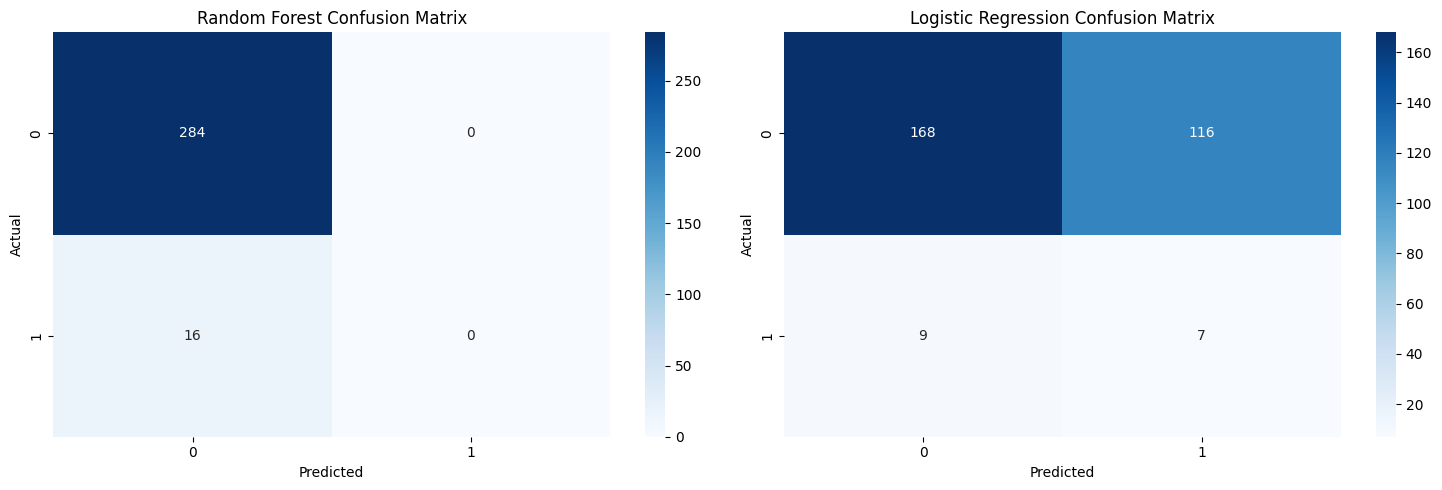

In [10]:
#5. Evaluate models
print("="*50)
print("RANDOM FOREST PERFORMANCE:")
print("="*50)
print(classification_report(y_test, y_pred_rf))

print("="*50)
print("LOGISTIC REGRESSION PERFORMANCE:")
print("="*50)
print(classification_report(y_test, y_pred_lr))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()



Feature Importance (preview):


,feature,importance
1,account_balance,0.147204
4,avg_trade_value,0.121361
5,avg_daily_trades,0.111818
2,tenure_days,0.107730
8,behavioral_risk_score,0.105299
3,trade_count,0.097104
0,age,0.093713
9,days_since_last_trade,0.080245
6,transaction_count,0.066457
7,deposit_ratio,0.045017


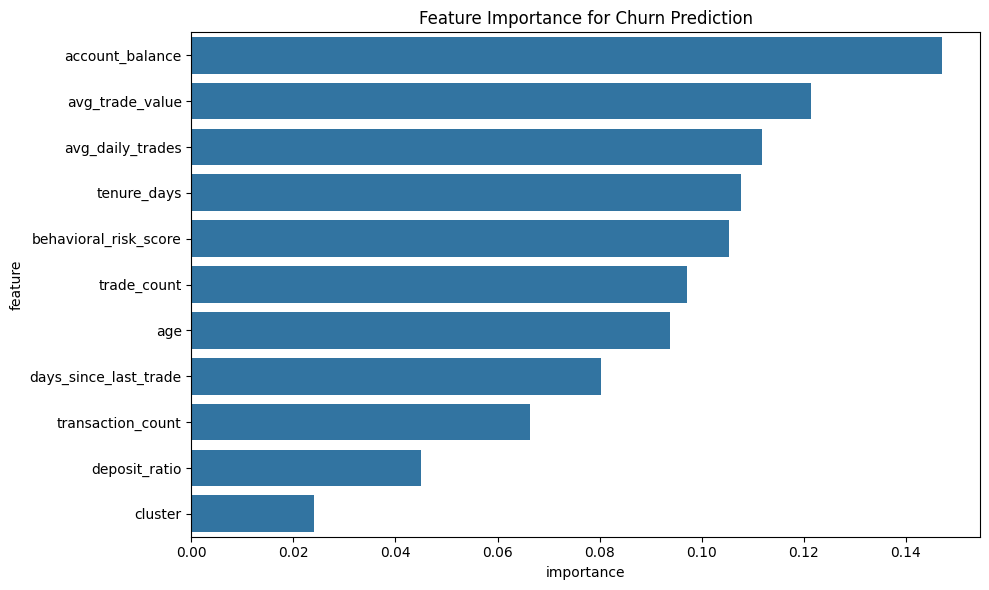

In [11]:
#6. feature importance
feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (preview):")
display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance for Churn Prediction')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

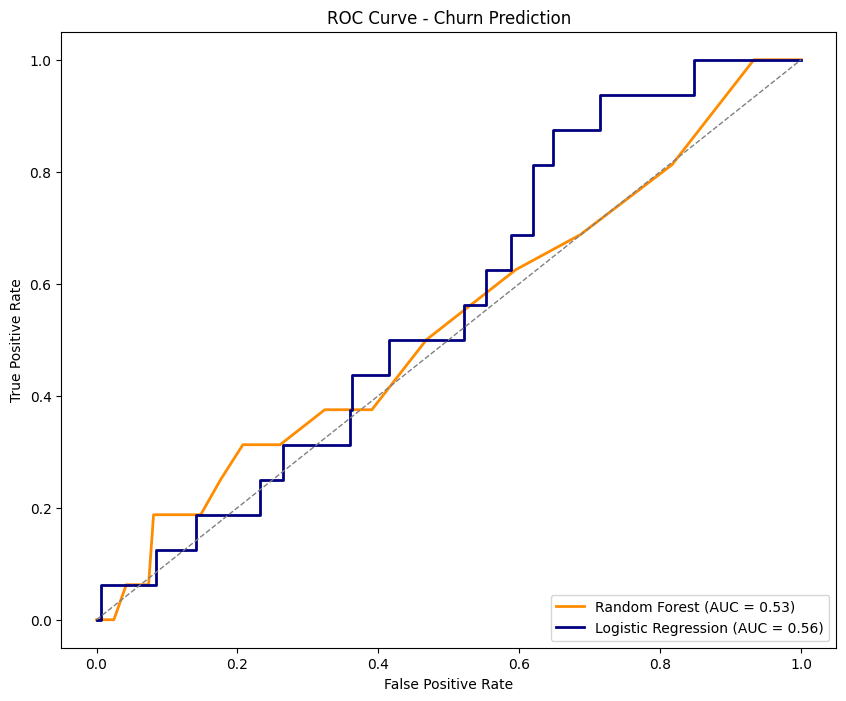

In [12]:
#7. ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_lr, tpr_lr, color='navy', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend(loc="lower right")
plt.savefig('../reports/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#8. create churn risk segments
client_data['churn_probability'] = rf_model.predict_proba(
    scaler.transform(imputer.transform(client_data[available_features]))
)[:, 1]

client_data['churn_risk_segment'] = pd.cut(
    client_data['churn_probability'],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("\nChurn Risk Distribution:")
print(client_data['churn_risk_segment'].value_counts())
display(client_data[['client_id', 'churn_probability', 'churn_risk_segment']].head())



Churn Risk Distribution:
churn_risk_segment
Low          755
High          37
Medium         8
Very High      0
Name: count, dtype: int64


,client_id,churn_probability,churn_risk_segment
0,C10000,0.02,Low
1,C10001,0.03,Low
2,C10002,0.00,NaN
3,C10003,0.01,Low
4,C10004,0.19,Low


In [14]:
#9. analyze churn by different segments
print("\nChurn Rate by Cluster:")
cluster_churn = client_data.groupby('cluster')['churned'].mean()
print(cluster_churn)

print("\nChurn Rate by Risk Tolerance:")
if 'risk_tolerance' in client_data.columns:
    risk_churn = client_data.groupby('risk_tolerance')['churned'].mean()
    print(risk_churn)

print("\nChurn Rate by Income Bracket:")
if 'income_bracket' in client_data.columns:
    income_churn = client_data.groupby('income_bracket')['churned'].mean()
    print(income_churn)


Churn Rate by Cluster:
cluster
0    0.046729
1    0.043011
2    0.062147
3    0.086957
Name: churned, dtype: float64

Churn Rate by Risk Tolerance:
risk_tolerance
High         0.071429
Low          0.058091
Medium       0.020161
Very High    0.061224
Name: churned, dtype: float64

Churn Rate by Income Bracket:
income_bracket
High      0.058824
Low       0.054711
Medium    0.045977
Name: churned, dtype: float64


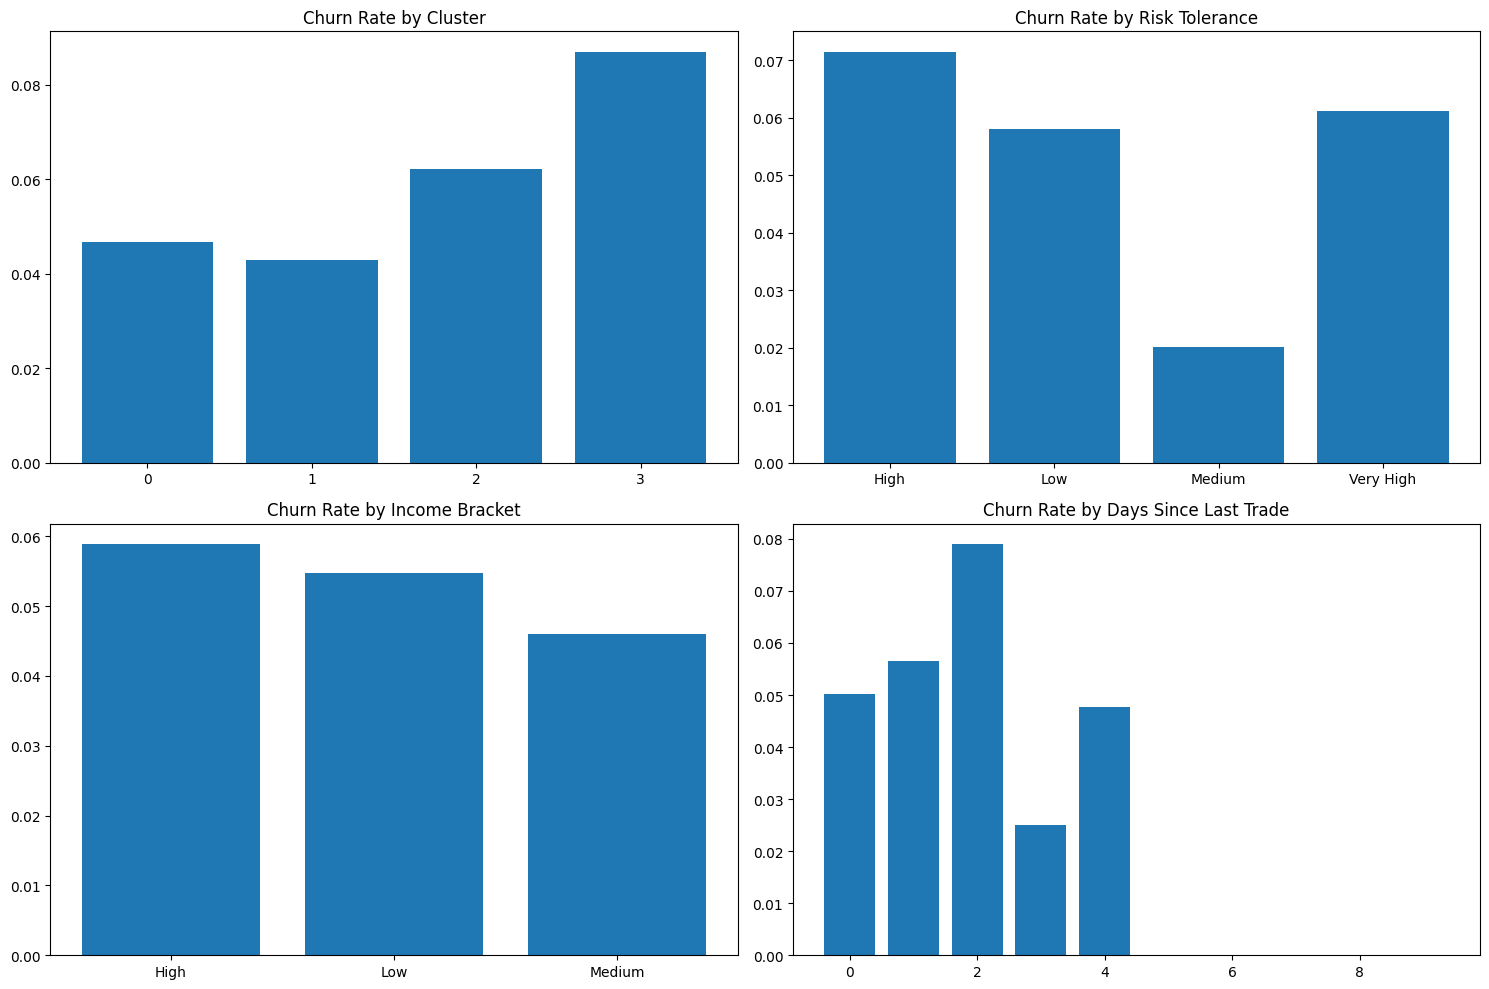

In [15]:
#10. visualize churn patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if 'cluster' in client_data.columns:
    churn_by_cluster = client_data.groupby('cluster')['churned'].mean()
    axes[0, 0].bar(churn_by_cluster.index.astype(str), churn_by_cluster.values)
    axes[0, 0].set_title('Churn Rate by Cluster')

if 'risk_tolerance' in client_data.columns:
    churn_by_risk = client_data.groupby('risk_tolerance')['churned'].mean()
    axes[0, 1].bar(churn_by_risk.index, churn_by_risk.values)
    axes[0, 1].set_title('Churn Rate by Risk Tolerance')

if 'income_bracket' in client_data.columns:
    churn_by_income = client_data.groupby('income_bracket')['churned'].mean()
    axes[1, 0].bar(churn_by_income.index, churn_by_income.values)
    axes[1, 0].set_title('Churn Rate by Income Bracket')

churn_by_days = client_data.groupby(pd.cut(client_data['days_since_last_trade'], bins=10))['churned'].mean()
axes[1, 1].bar(range(len(churn_by_days)), churn_by_days.values)
axes[1, 1].set_title('Churn Rate by Days Since Last Trade')

plt.tight_layout()
plt.savefig('../reports/churn_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
#11. save results
client_data.to_csv('../data/processed/client_data_with_churn.csv', index=False)

In [17]:
#12. identify high-risk clients
high_risk_clients = client_data[
    client_data['churn_risk_segment'].isin(['High', 'Very High'])
][[
    'client_id', 'age', 'risk_tolerance', 'account_balance',
    'trade_count', 'days_since_last_trade', 'churn_probability', 'churn_risk_segment'
]].sort_values('churn_probability', ascending=False)

print(f"\nNumber of high-risk clients: {len(high_risk_clients)}")
print("\nTop 10 high-risk clients:")
display(high_risk_clients.head(10))

high_risk_clients.to_csv('../data/processed/high_risk_clients.csv', index=False)

print("\n✅ Churn prediction modeling completed!")


Number of high-risk clients: 37

Top 10 high-risk clients:


,client_id,age,risk_tolerance,account_balance,trade_count,days_since_last_trade,churn_probability,churn_risk_segment
285,C10285,24,High,6467,114,1,0.77,High
563,C10563,23,Low,9995,119,9,0.72,High
610,C10610,22,Very High,19070,121,17,0.72,High
640,C10640,35,Low,5128,102,9,0.72,High
957,C10957,66,High,18420,98,1,0.72,High
599,C10599,27,Low,9564,115,9,0.68,High
821,C10821,58,Low,28630,93,3,0.68,High
515,C10515,32,Very High,6340,98,8,0.68,High
356,C10356,26,High,46138,102,3,0.68,High
335,C10335,53,Medium,26100,94,6,0.68,High



✅ Churn prediction modeling completed!
